In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten, Convolution1D, Dropout
from keras.optimizers import SGD
from keras.initializers import random_uniform

In [ ]:
dftrain = pd.read_csv('/content/FVthermo.csv')
#df.head()

In [ ]:
##Label and ID represent dataset

Y=dftrain['Label']
X=dftrain.drop(['Label'],axis=1)


In [ ]:
# Convert all non-numeric values to NaN and then handle them
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
# Option 1: Drop rows with NaN values
X = X.dropna()

In [ ]:
# Option 2: Fill NaN values with a default value (e.g., 0)
# X = X.fillna(0)

# Ensure the target labels are aligned with the cleaned features
Y = Y.loc[X.index]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [ ]:

# Normalize the feature data
X = X.to_numpy()
Y = Y.to_numpy()
scaler = MinMaxScaler().fit(X)
X = scaler.transform(X)
X = np.nan_to_num(X.astype('float32'))

In [ ]:
# libaray For differnt measure
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import precision_score, matthews_corrcoef, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score, roc_auc_score, precision_score, matthews_corrcoef, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
##Split Data
from sklearn.metrics import accuracy_score
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
from sklearn.manifold import TSNE
from sklearn.datasets import make_moons, make_circles, make_classification
import matplotlib.pyplot as plt

In [ ]:
pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


Dataset Shape: (4480, 154)
Feature shape: (4480, 153)
Label shape: (4480,)
Class Distribution: Label
0    2445
1    2035
Name: count, dtype: int64

Training: Logistic Regression
Logistic Regression -> Accuracy:91.07% | Balanced:91.04% | F1:90.22% | Precision:89.78% | MCC:82.01% | AUC:97.05159705159704

Training: SVM
SVM -> Accuracy:86.27% | Balanced:86.95% | F1:86.20% | Precision:79.34% | MCC:73.83% | AUC:96.4612130256302

Training: Decision Tree
Decision Tree -> Accuracy:83.15% | Balanced:82.79% | F1:80.96% | Precision:83.16% | MCC:65.94% | AUC:82.78867266597328

Training: KNN
KNN -> Accuracy:88.73% | Balanced:89.14% | F1:88.30% | Precision:83.55% | MCC:77.96% | AUC:94.87320560940192

Training: Naive Bayes
Naive Bayes -> Accuracy:55.47% | Balanced:59.00% | F1:66.55% | Precision:50.51% | MCC:27.30% | AUC:59.080357546615225

Training: Gradient Boosting
Gradient Boosting -> Accuracy:90.85% | Balanced:90.87% | F1:90.05% | Precision:88.97% | MCC:81.60% | AUC:96.72701145093782

Training: Ra

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM -> Accuracy:91.18% | Balanced:91.22% | F1:90.42% | Precision:89.23% | MCC:82.28% | AUC:97.81432296769721

Training: CatBoost
CatBoost -> Accuracy:92.19% | Balanced:92.27% | F1:91.55% | Precision:90.02% | MCC:84.33% | AUC:97.9479758620863


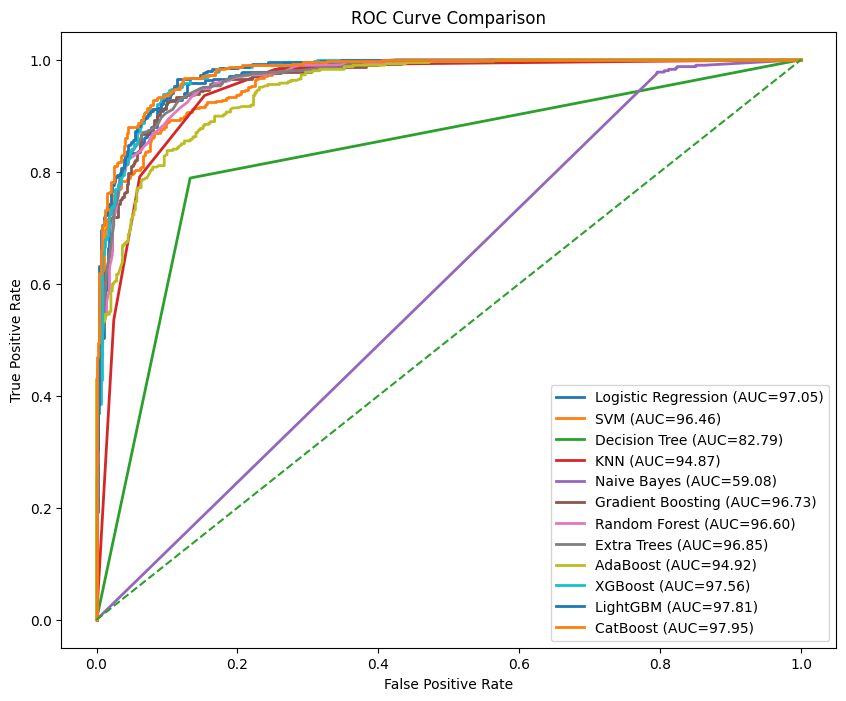

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_csv("/content/FVthermo.csv")

print("Dataset Shape:", df.shape)

# -----------------------------
# FEATURES AND LABEL
# -----------------------------
X = df.iloc[:, :-1]   # 153 features
Y = df.iloc[:, -1]    # label column

print("Feature shape:", X.shape)
print("Label shape:", Y.shape)

print("Class Distribution:", Y.value_counts())


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


# -----------------------------
# FEATURE SCALING
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -----------------------------
# MODELS
# -----------------------------
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=2000),

    "SVM":
        SVC(probability=True),

    "Decision Tree":
        DecisionTreeClassifier(),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "Extra Trees":
        ExtraTreesClassifier(),

    "AdaBoost":
        AdaBoostClassifier(),

    "XGBoost":
        XGBClassifier(eval_metric='logloss'),

    "LightGBM":
        LGBMClassifier(),

    "CatBoost":
        CatBoostClassifier(verbose=0)
}


# -----------------------------
# ROC PLOT
# -----------------------------
plt.figure(figsize=(10,8))

results = {}

for name, model in models.items():

    print("\nTraining:", name)

    model.fit(X_train, Y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:,1]
    else:
        y_probs = None


    # Metrics
    accuracy = accuracy_score(Y_test, y_pred)*100
    balanced_acc = balanced_accuracy_score(Y_test, y_pred)*100
    f1 = f1_score(Y_test, y_pred)*100
    precision = precision_score(Y_test, y_pred)*100
    mcc = matthews_corrcoef(Y_test, y_pred)*100

    roc_auc = None
    if y_probs is not None:
        roc_auc = roc_auc_score(Y_test, y_probs)*100


    print(
        f"{name} -> "
        f"Accuracy:{accuracy:.2f}% | "
        f"Balanced:{balanced_acc:.2f}% | "
        f"F1:{f1:.2f}% | "
        f"Precision:{precision:.2f}% | "
        f"MCC:{mcc:.2f}% | "
        f"AUC:{roc_auc if roc_auc else 'N/A'}"
    )


    if y_probs is not None:
        fpr, tpr, _ = roc_curve(Y_test, y_probs)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.2f})')


# -----------------------------
# FINAL ROC CURVE
# -----------------------------
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")

plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, matthews_corrcoef, roc_auc_score, precision_score
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    matthews_corrcoef,
    roc_auc_score
)

model_file = "svm_best_model_thermo_Indep.pkl"


# ---------------------------------------------------
# CHECK IF MODEL ALREADY EXISTS
# ---------------------------------------------------
if os.path.exists(model_file):

    print("Saved model found. Loading model...")

    best_model = joblib.load(model_file)

else:

    print("No saved model found. Training SVM with GridSearch...")

    svc = SVC(kernel='rbf', probability=True)

    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': [0.1, 1, 10]
    }

    grid_search = GridSearchCV(
        svc,
        param_grid,
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, Y_train)

    best_model = grid_search.best_estimator_

    print("Best Parameters:", grid_search.best_params_)

    # Save model
    joblib.dump(best_model, model_file)

    print("Model saved as svm_best_model.pkl")


# ---------------------------------------------------
# PREDICTION (TEST SET)
# ---------------------------------------------------
svc_pred_test = best_model.predict(X_test)
svc_prob_test = best_model.predict_proba(X_test)[:,1]

# ---------------------------------------------------
# PREDICTION (TRAIN SET)
# ---------------------------------------------------
svc_pred_train = best_model.predict(X_train)
svc_prob_train = best_model.predict_proba(X_train)[:,1]


# ---------------------------------------------------
# FUNCTION TO CALCULATE METRICS
# ---------------------------------------------------
def evaluate_model(y_true, y_pred, y_prob):

    acc = accuracy_score(y_true, y_pred)*100
    bal_acc = balanced_accuracy_score(y_true, y_pred)*100
    f1 = f1_score(y_true, y_pred)*100
    precision = precision_score(y_true, y_pred)*100
    mcc = matthews_corrcoef(y_true, y_pred)*100
    roc_auc = roc_auc_score(y_true, y_prob)*100

    cm = confusion_matrix(y_true, y_pred)

    sensitivity = (cm[0,0] / (cm[0,0] + cm[0,1]))*100
    specificity = (cm[1,1] / (cm[1,0] + cm[1,1]))*100

    return acc, bal_acc, sensitivity, specificity, f1, precision, mcc, roc_auc, cm


# ---------------------------------------------------
# TRAIN PERFORMANCE
# ---------------------------------------------------
train_results = evaluate_model(Y_train, svc_pred_train, svc_prob_train)

# ---------------------------------------------------
# TEST PERFORMANCE
# ---------------------------------------------------
test_results = evaluate_model(Y_test, svc_pred_test, svc_prob_test)


# ---------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------
print("\n========== TRAIN RESULTS ==========")

print("Accuracy:", train_results[0])
print("Balanced Accuracy:", train_results[1])
print("Sensitivity:", train_results[2])
print("Specificity:", train_results[3])
print("F1 Score:", train_results[4])
print("Precision:", train_results[5])
print("MCC:", train_results[6])
print("ROC AUC:", train_results[7])
print("Confusion Matrix:\n", train_results[8])


print("\n========== TEST RESULTS ==========")

print("Accuracy:", test_results[0])
print("Balanced Accuracy:", test_results[1])
print("Sensitivity:", test_results[2])
print("Specificity:", test_results[3])
print("F1 Score:", test_results[4])
print("Precision:", test_results[5])
print("MCC:", test_results[6])
print("ROC AUC:", test_results[7])
print("Confusion Matrix:\n", test_results[8])


# ---------------------------------------------------
# SAVE RESULTS
# ---------------------------------------------------
results = {
    "Train Accuracy": train_results[0],
    "Train Balanced Accuracy": train_results[1],
    "Train F1": train_results[4],
    "Train Precision": train_results[5],
    "Train MCC": train_results[6],
    "Train AUC": train_results[7],

    "Test Accuracy": test_results[0],
    "Test Balanced Accuracy": test_results[1],
    "Test F1": test_results[4],
    "Test Precision": test_results[5],
    "Test MCC": test_results[6],
    "Test AUC": test_results[7]
}

df_results = pd.DataFrame([results])

df_results.to_csv("svm_results_themo.csv", index=False)

print("\nResults saved as svm_results.csv")

No saved model found. Training SVM with GridSearch...
Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [ ]:
# Get probability scores for ROC
# Compute ROC curve
svc_scores = best_model.predict_proba(X_test)[:, 1]

# Get decision function scores for ROC Curve on independent test set
# svc_pred_test = svc_prob_test.decision_function(X_test)  # Use X_test instead of Y_test

# Calculate ROC Curve for independent test set
fpr_indep, tpr_indep, _ = roc_curve(Y_test, svc_scores)  # Use Y_test for true labels

# Calculate AUC for the ROC Curve
roc_auc_indep = auc(fpr_indep, tpr_indep)

# Plot ROC Curve for independent test set
plt.figure(figsize=(8, 6))
plt.plot(fpr_indep, tpr_indep, color='darkorange', lw=2, label='ROC curve (SVM AUC = %0.3f)' % roc_auc_indep)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Independent Test Set')
plt.legend(loc="lower right")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_auc_score
)


In [ ]:
rfc = RandomForestClassifier(
    n_estimators=42,        # strong ensemble
    max_depth=25,             # controls overfitting
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',      # best for classification
    bootstrap=True,
    class_weight='balanced',  # VERY IMPORTANT
    random_state=42,
    n_jobs=-1
)


In [ ]:
rfc.fit(X_train, Y_train)


In [ ]:
y_pred = rfc.predict(X_test)
y_prob = rfc.predict_proba(X_test)[:, 1]


In [ ]:
cm = confusion_matrix(Y_test, y_pred)

TN, FP, FN, TP = cm.ravel()


In [ ]:
accuracy = accuracy_score(Y_test, y_pred) * 100
balanced_acc = balanced_accuracy_score(Y_test, y_pred) * 100
precision = precision_score(Y_test, y_pred) * 100
recall = recall_score(Y_test, y_pred) * 100          # Sensitivity
specificity = TN / (TN + FP) * 100
f1 = f1_score(Y_test, y_pred) * 100
mcc = matthews_corrcoef(Y_test, y_pred) * 100
roc_auc = roc_auc_score(Y_test, y_prob) * 100
print("\n--- Random Forest Test Metrics ---")
print(f"Accuracy: {accuracy:.3f}%")
print(f"Balanced Accuracy: {balanced_acc:.3f}%")
print(f"Precision: {precision:.3f}%")
print(f"Sensitivity (Recall): {recall:.3f}%")
print(f"Specificity: {specificity:.3f}%")
print(f"F1-score: {f1:.3f}%")
print(f"MCC: {mcc:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}%")
print("Confusion Matrix:\n", cm)



--- Random Forest Test Metrics ---
Accuracy: 89.621%
Balanced Accuracy: 89.605%
Precision: 87.923%
Sensitivity (Recall): 89.435%
Specificity: 89.775%
F1-score: 88.672%
MCC: 79.106
ROC-AUC: 96.542%
Confusion Matrix:
 [[439  50]
 [ 43 364]]


In [ ]:
import os
import joblib
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    precision_score,
    recall_score
)

model_file = "rfc_model_thermo.pkl"

# ---------------------------------------------------
# TRAIN RANDOM FOREST MODEL
# ---------------------------------------------------
rfc = RandomForestClassifier(
    n_estimators=270,
    random_state=42,
    n_jobs=-1
)

rfc.fit(X_train, Y_train)

# -----------------------------
# SAVE TRAINED MODEL
# -----------------------------
joblib.dump(rfc, model_file)
print(f"Model saved as {model_file}")

# ---------------------------------------------------
# TRAIN PREDICTION
# ---------------------------------------------------
train_pred = rfc.predict(X_train)
train_prob = rfc.predict_proba(X_train)[:,1]

# ---------------------------------------------------
# TEST PREDICTION
# ---------------------------------------------------
test_pred = rfc.predict(X_test)
test_prob = rfc.predict_proba(X_test)[:,1]

# ---------------------------------------------------
# FUNCTION FOR METRICS
# ---------------------------------------------------
def evaluate(y_true, y_pred, y_prob):

    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred) * 100
    balanced_acc = balanced_accuracy_score(y_true, y_pred) * 100
    precision = precision_score(y_true, y_pred) * 100
    recall = recall_score(y_true, y_pred) * 100
    specificity = TN / (TN + FP) * 100
    f1 = f1_score(y_true, y_pred) * 100
    mcc = matthews_corrcoef(y_true, y_pred) * 100
    roc_auc = roc_auc_score(y_true, y_prob) * 100

    return accuracy, balanced_acc, precision, recall, specificity, f1, mcc, roc_auc, cm



# ---------------------------------------------------
# TEST RESULTS
# ---------------------------------------------------
test_results = evaluate(Y_test, test_pred, test_prob)

print("\n===== TEST RESULTS =====")
print("Accuracy:", test_results[0])
print("Balanced Accuracy:", test_results[1])
print("Precision:", test_results[2])
print("Sensitivity:", test_results[3])
print("Specificity:", test_results[4])
print("F1 Score:", test_results[5])
print("MCC:", test_results[6])
print("ROC AUC:", test_results[7])
print("Confusion Matrix:\n", test_results[8])

# ---------------------------------------------------
# SAVE RESULTS
# ---------------------------------------------------
results = {
    "Train Accuracy": train_results[0],
    "Train Balanced Accuracy": train_results[1],
    "Train F1": train_results[5],
    "Train MCC": train_results[6],
    "Train AUC": train_results[7],

    "Test Accuracy": test_results[0],
    "Test Balanced Accuracy": test_results[1],
    "Test F1": test_results[5],
    "Test MCC": test_results[6],
    "Test AUC": test_results[7]
}

df = pd.DataFrame([results])
df.to_csv("rfc_results.csv", index=False)

print("\nResults saved to rfc_results.csv")

Model saved as rfc_model_thermo.pkl

===== TEST RESULTS =====
Accuracy: 91.18303571428571
Balanced Accuracy: 91.26307009742592
Precision: 88.86255924170617
Sensitivity: 92.13759213759214
Specificity: 90.38854805725971
F1 Score: 90.47044632086852
MCC: 82.31856122921866
ROC AUC: 97.0043663295197
Confusion Matrix:
 [[442  47]
 [ 32 375]]

Results saved to rfc_results.csv


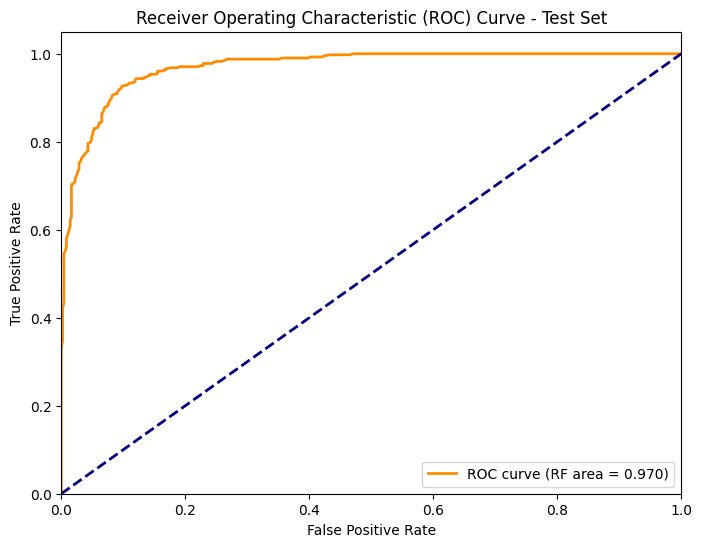

In [ ]:
# Calculate probabilities for ROC Curve on test set
rfc_probs_test = rfc.predict_proba(X_test)[:, 1]  # Probabilities of positive class (class 1)

# Calculate ROC Curve for test set
fpr_test, tpr_test, _ = roc_curve(Y_test, rfc_probs_test)
roc_auc_test = roc_auc_score(Y_test, rfc_probs_test)

# Plot ROC Curve for test set
plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label='ROC curve (RF area = %0.3f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, matthews_corrcoef, roc_auc_score, precision_score


In [ ]:
import joblib
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    precision_score,
    recall_score
)

model_file = "etc_model_thermo_independent.pkl"

# ---------------------------------------------------
# TRAIN MODEL (ONLY ON TRAIN DATA)
# ---------------------------------------------------
etc = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

etc.fit(X_train, Y_train)

# ---------------------------------------------------
# SAVE MODEL
# ---------------------------------------------------
joblib.dump(etc, model_file)
print(f"Model saved as {model_file}")

# ---------------------------------------------------
# INDEPENDENT TEST (ONLY TEST DATA USED HERE)
# ---------------------------------------------------
y_pred = etc.predict(X_test)
y_prob = etc.predict_proba(X_test)[:, 1]

# ---------------------------------------------------
# METRICS CALCULATION
# ---------------------------------------------------
cm = confusion_matrix(Y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

accuracy = accuracy_score(Y_test, y_pred) * 100
balanced_acc = balanced_accuracy_score(Y_test, y_pred) * 100
precision = precision_score(Y_test, y_pred) * 100
recall = recall_score(Y_test, y_pred) * 100
specificity = TN / (TN + FP) * 100
f1 = f1_score(Y_test, y_pred) * 100
mcc = matthews_corrcoef(Y_test, y_pred) * 100
roc_auc = roc_auc_score(Y_test, y_prob) * 100

# ---------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------
print("\n===== INDEPENDENT TEST RESULTS =====")
print(f"Accuracy: {accuracy:.6f}%")
print(f"Balanced Accuracy: {balanced_acc:.6f}%")
print(f"Precision: {precision:.6f}%")
print(f"Sensitivity (Recall): {recall:.6f}%")
print(f"Specificity: {specificity:.6f}%")
print(f"F1 Score: {f1:.6f}%")
print(f"MCC: {mcc:.6f}")
print(f"ROC AUC: {roc_auc:.6f}%")
print("Confusion Matrix:\n", cm)

# ---------------------------------------------------
# SAVE RESULTS
# ---------------------------------------------------
results = pd.DataFrame([{
    "Accuracy": accuracy,
    "Balanced Accuracy": balanced_acc,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1 Score": f1,
    "MCC": mcc,
    "ROC AUC": roc_auc
}])

results.to_csv("independent_test_results.csv", index=False)

print("\nResults saved to independent_test_results.csv")

Model saved as etc_model_thermo_independent.pkl

===== INDEPENDENT TEST RESULTS =====
Accuracy: 91.071429%
Balanced Accuracy: 91.099019%
Precision: 89.208633%
Sensitivity (Recall): 91.400491%
Specificity: 90.797546%
F1 Score: 90.291262%
MCC: 82.049757
ROC AUC: 97.204092%
Confusion Matrix:
 [[444  45]
 [ 35 372]]

Results saved to independent_test_results.csv


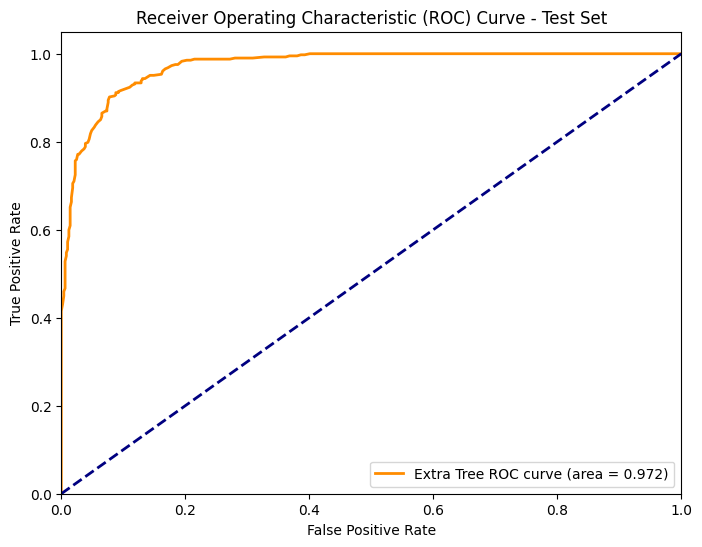

In [ ]:
# Calculate probabilities for ROC Curve on test set
etc_probs_test = etc.predict_proba(X_test)[:, 1]  # Probabilities of positive class (class 1)

# Calculate ROC Curve for test set
etc_fpr_test, etc_tpr_test, _ = roc_curve(Y_test, etc_probs_test)
etc_roc_auc_test = roc_auc_score(Y_test, etc_probs_test)

# Plot ROC Curve for test set
plt.figure(figsize=(8, 6))
plt.plot(etc_fpr_test, etc_tpr_test, color='darkorange', lw=2, label='Extra Tree ROC curve (area = %0.3f)' % etc_roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc="lower right")
plt.show()


In [ ]:
import joblib
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    precision_score,
    recall_score
)

model_file = "lgbm_model_thermo.pkl"

# ----------------------------
# TRAIN LightGBM
# ----------------------------
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, Y_train)

# ----------------------------
# SAVE TRAINED MODEL
# ----------------------------
joblib.dump(lgbm, model_file)
print(f"Model saved as {model_file}")

# ----------------------------
# PREDICTIONS
# ----------------------------
train_pred = lgbm.predict(X_train)
train_prob = lgbm.predict_proba(X_train)[:,1]

test_pred = lgbm.predict(X_test)
test_prob = lgbm.predict_proba(X_test)[:,1]

# ----------------------------
# METRICS FUNCTION
# ----------------------------
def evaluate(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)*100
    balanced_acc = balanced_accuracy_score(y_true, y_pred)*100
    precision = precision_score(y_true, y_pred)*100
    recall = recall_score(y_true, y_pred)*100
    specificity = TN / (TN + FP)*100
    f1 = f1_score(y_true, y_pred)*100
    mcc = matthews_corrcoef(y_true, y_pred)*100
    roc_auc = roc_auc_score(y_true, y_prob)*100

    return accuracy, balanced_acc, precision, recall, specificity, f1, mcc, roc_auc, cm


# ----------------------------
# TEST RESULTS
# ----------------------------
test_results = evaluate(Y_test, test_pred, test_prob)
print("\n===== TEST RESULTS =====")
print("Accuracy:", test_results[0])
print("Balanced Accuracy:", test_results[1])
print("Precision:", test_results[2])
print("Sensitivity:", test_results[3])
print("Specificity:", test_results[4])
print("F1 Score:", test_results[5])
print("MCC:", test_results[6])
print("ROC AUC:", test_results[7])
print("Confusion Matrix:\n", test_results[8])

# ----------------------------
# SAVE RESULTS
# ----------------------------
results = {
    "Train Accuracy": train_results[0],
    "Train Balanced Accuracy": train_results[1],
    "Train F1": train_results[5],
    "Train MCC": train_results[6],
    "Train AUC": train_results[7],

    "Test Accuracy": test_results[0],
    "Test Balanced Accuracy": test_results[1],
    "Test F1": test_results[5],
    "Test MCC": test_results[6],
    "Test AUC": test_results[7]
}

df = pd.DataFrame([results])
df.to_csv("lgbm_results.csv", index=False)
print("\nResults saved to lgbm_results.csv")

[LightGBM] [Info] Number of positive: 1628, number of negative: 1956
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019472 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32772
[LightGBM] [Info] Number of data points in the train set: 3584, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.454241 -> initscore=-0.183549
[LightGBM] [Info] Start training from score -0.183549
Model saved as lgbm_model_thermo.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== TEST RESULTS =====
Accuracy: 92.07589285714286
Balanced Accuracy: 92.1222672756415
Precision: 90.19138755980862
Sensitivity: 92.62899262899262
Specificity: 91.61554192229039
F1 Score: 91.39393939393939
MCC: 84.0797245304317
ROC AUC: 98.08363857443612
Confusion Matrix:
 [[448  41]
 [ 30 377]]

Results saved to lgbm_results.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


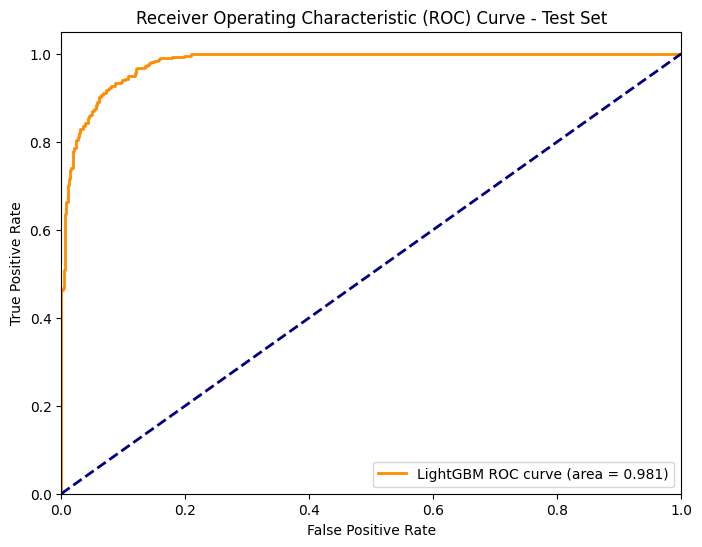

In [ ]:
# ----------------------------
# Calculate probabilities for ROC Curve on test set (LightGBM)
# ----------------------------
lgbm_probs_test = lgbm.predict_proba(X_test)[:, 1]  # Probabilities of positive class (class 1)

# ----------------------------
# Calculate ROC Curve for test set
# ----------------------------
lgbm_fpr_test, lgbm_tpr_test, _ = roc_curve(Y_test, lgbm_probs_test)
lgbm_roc_auc_test = roc_auc_score(Y_test, lgbm_probs_test)

# ----------------------------
# Plot ROC Curve for test set
# ----------------------------
plt.figure(figsize=(8, 6))
plt.plot(
    lgbm_fpr_test,
    lgbm_tpr_test,
    color='darkorange',
    lw=2,
    label='LightGBM ROC curve (area = %0.3f)' % lgbm_roc_auc_test
)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import joblib
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    precision_score,
    recall_score
)

model_file = "catboost_model_thermo2final_Indep.pkl"

# ----------------------------
# TRAIN CatBoost
# ----------------------------
catb = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

catb.fit(X_train, Y_train)

# ----------------------------
# SAVE TRAINED MODEL
# ----------------------------
joblib.dump(catb, model_file)
print(f"Model saved as {model_file}")

# ----------------------------
# PREDICTIONS
# ----------------------------
train_pred = catb.predict(X_train)
train_prob = catb.predict_proba(X_train)[:,1]

test_pred = catb.predict(X_test)
test_prob = catb.predict_proba(X_test)[:,1]

# ----------------------------
# METRICS FUNCTION
# ----------------------------
def evaluate(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)*100
    balanced_acc = balanced_accuracy_score(y_true, y_pred)*100
    precision = precision_score(y_true, y_pred)*100
    recall = recall_score(y_true, y_pred)*100
    specificity = TN / (TN + FP)*100
    f1 = f1_score(y_true, y_pred)*100
    mcc = matthews_corrcoef(y_true, y_pred)*100
    roc_auc = roc_auc_score(y_true, y_prob)*100

    return accuracy, balanced_acc, precision, recall, specificity, f1, mcc, roc_auc, cm



# ----------------------------
# TEST RESULTS
# ----------------------------
test_results = evaluate(Y_test, test_pred, test_prob)
print("\n===== TEST RESULTS =====")
print("Accuracy:", test_results[0])
print("Balanced Accuracy:", test_results[1])
print("Precision:", test_results[2])
print("Sensitivity:", test_results[3])
print("Specificity:", test_results[4])
print("F1 Score:", test_results[5])
print("MCC:", test_results[6])
print("ROC AUC:", test_results[7])
print("Confusion Matrix:\n", test_results[8])

# ----------------------------
# SAVE RESULTS
# ----------------------------
results = {


    "Test Accuracy": test_results[0],
    "Test Balanced Accuracy": test_results[1],
    "Test F1": test_results[5],
    "Test MCC": test_results[6],
    "Test AUC": test_results[7]
}

df = pd.DataFrame([results])
df.to_csv("catboost_results.csv", index=False)
print("\nResults saved to catboost_results.csv")

Model saved as catboost_model_thermo2final_Indep.pkl

===== TEST RESULTS =====
Accuracy: 92.29910714285714
Balanced Accuracy: 92.36796752134175
Precision: 90.23809523809524
Sensitivity: 93.12039312039312
Specificity: 91.61554192229039
F1 Score: 91.65659008464328
MCC: 84.5456249592435
ROC AUC: 97.75905297377689
Confusion Matrix:
 [[448  41]
 [ 28 379]]

Results saved to catboost_results.csv


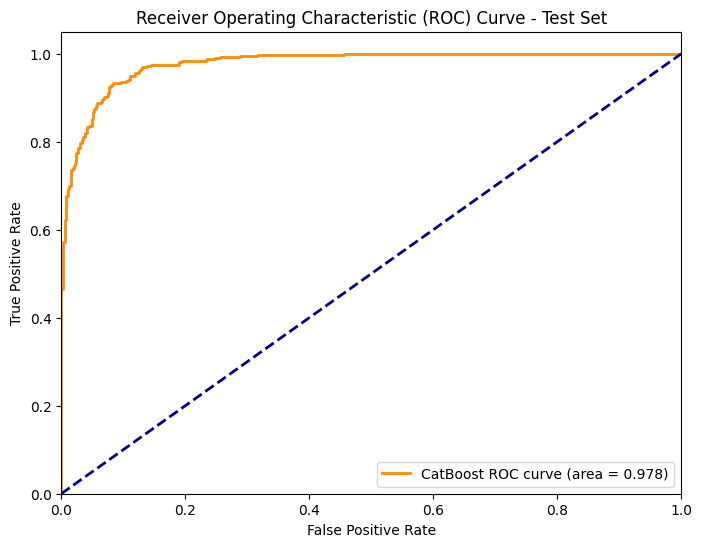

In [ ]:
# ----------------------------
# Calculate probabilities for ROC Curve on test set (CatBoost)
# ----------------------------
catb_probs_test = catb.predict_proba(X_test)[:, 1]  # Probabilities of positive class (class 1)

# ----------------------------
# Calculate ROC Curve for test set
# ----------------------------
catb_fpr_test, catb_tpr_test, _ = roc_curve(Y_test, catb_probs_test)
catb_roc_auc_test = roc_auc_score(Y_test, catb_probs_test)

# ----------------------------
# Plot ROC Curve for test set
# ----------------------------
plt.figure(figsize=(8, 6))
plt.plot(
    catb_fpr_test,
    catb_tpr_test,
    color='darkorange',
    lw=2,
    label='CatBoost ROC curve (area = %0.3f)' % catb_roc_auc_test
)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc="lower right")
plt.show()

Deep Learning

In [ ]:
import joblib
import pandas as pd
from tensorflow.keras.models import save_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, matthews_corrcoef, recall_score

# Early Stopping and Learning Rate Reduction Callbacks
earlystop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Define CNN Model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, padding='same', activation='relu', input_shape=(153, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the Model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 153, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 76, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 76, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 76, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 38, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 19, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4864)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       622,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 746,369 (2.85 MB)

 Trainable params: 746,369 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.fit(X_train, Y_train, validation_split=0.2,batch_size=64, epochs=100, verbose=1)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.6240 - loss: 0.6292 - val_accuracy: 0.6374 - val_loss: 0.6315
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.6592 - loss: 0.6112 - val_accuracy: 0.6569 - val_loss: 0.6103
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.7074 - loss: 0.5623 - val_accuracy: 0.8020 - val_loss: 0.4677
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - accuracy: 0.7994 - loss: 0.4363 - val_accuracy: 0.8801 - val_loss: 0.3221
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8451 - loss: 0.3519 - val_accuracy: 0.8787 - val_loss: 0.2840
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.8552 - loss: 0.3261 - val_accuracy: 0.8870 - val_loss: 0.2659
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8716 - loss: 0.2972 - val_accuracy: 0.8926 - val_loss: 0.2652
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.8737 - loss: 0.2923 - val_accuracy:

In [ ]:
# Evaluate on Test Set
predictions = cnn_model.predict(X_test).flatten()
y_pred = (predictions > 0.5).astype(int)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
# # ----------------------------
# # LOAD SAVED CNN MODEL
# # ----------------------------
# model_file = "cnn_model.h5"
# cnn_model = load_model(model_file)
# print(f"Loaded CNN model from {model_file}")

# ----------------------------
# MAKE PREDICTIONS ON TEST SET
# ----------------------------
predictions = cnn_model.predict(X_test).flatten()
y_pred = (predictions > 0.5).astype(int)

# ----------------------------
# CALCULATE METRICS
# ----------------------------
accuracy = accuracy_score(Y_test, y_pred)
ba = balanced_accuracy_score(Y_test, y_pred)
cm = confusion_matrix(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
mcc = matthews_corrcoef(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

# ----------------------------
# PRINT METRICS
# ----------------------------
print("\n--- CNN Test Metrics (Loaded Model) ---")
print(f"Accuracy: {accuracy * 100:.3f}%")
print(f"Balanced Accuracy: {ba * 100:.3f}%")
print(f"F1-Score: {f1 * 100:.3f}%")
print(f"Precision: {precision * 100:.3f}%")
print(f"Matthews Correlation Coefficient: {mcc:.3f}")
print(f"Sensitivity (Recall): {recall * 100:.3f}%")
print(f"Specificity: {specificity * 100:.3f}%")
print(f"Confusion Matrix:\n{cm}")

# ----------------------------
# SAVE RESULTS TO CSV
# ----------------------------
results = {
    "Test Accuracy": accuracy * 100,
    "Test Balanced Accuracy": ba * 100,
    "Test F1": f1 * 100,
    "Test Precision": precision * 100,
    "Test MCC": mcc,
    "Test Sensitivity": recall * 100,
    "Test Specificity": specificity * 100
}

df_results = pd.DataFrame([results])
df_results.to_csv("cnn_results_loaded_model1final.csv", index=False)
print("Results saved to cnn_results_loaded_model.csv")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- CNN Test Metrics (Loaded Model) ---
Accuracy: 91.295%
Balanced Accuracy: 91.324%
F1-Score: 90.534%
Precision: 89.448%
Matthews Correlation Coefficient: 0.825
Sensitivity (Recall): 91.646%
Specificity: 91.002%
Confusion Matrix:
[[445  44]
 [ 34 373]]
Results saved to cnn_results_loaded_model.csv


In [ ]:
# Calculate Metrics
accuracy = accuracy_score(Y_test, y_pred)
ba = balanced_accuracy_score(Y_test, y_pred)
cm = confusion_matrix(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
mcc = matthews_corrcoef(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

# Print Metrics
print("\n--- CNN Test Metrics ---")
print(f"Accuracy: {accuracy * 100:.3f}%")
print(f"Balanced Accuracy: {ba * 100:.3f}%")
print(f"F1-Score: {f1 * 100:.3f}%")
print(f"Precision: {precision * 100:.3f}%")
print(f"Matthews Correlation Coefficient: {mcc:.3f}")
print(f"Sensitivity (Recall): {recall * 100:.3f}%")
print(f"Specificity: {specificity * 100:.3f}%")
print(f"Confusion Matrix:\n{cm}")


--- CNN Test Metrics ---
Accuracy: 91.295%
Balanced Accuracy: 91.324%
F1-Score: 90.534%
Precision: 89.448%
Matthews Correlation Coefficient: 0.825
Sensitivity (Recall): 91.646%
Specificity: 91.002%
Confusion Matrix:
[[445  44]
 [ 34 373]]


In [ ]:
# ----------------------------
# SAVE CNN MODEL
# ----------------------------
model_file = "cnn_model-1Dthermo.h5"
cnn_model.save(model_file)
print(f"CNN model saved as {model_file}")

# ----------------------------
# SAVE RESULTS TO CSV
# ----------------------------
results = {
    "Test Accuracy": accuracy * 100,
    "Test Balanced Accuracy": ba * 100,
    "Test F1": f1 * 100,
    "Test Precision": precision * 100,
    "Test MCC": mcc,
    "Test Sensitivity": recall * 100,
    "Test Specificity": specificity * 100
}

df_results = pd.DataFrame([results])
df_results.to_csv("cnn_results.csv", index=False)
print("CNN results saved to cnn_results.csv")

CNN model saved as cnn_model-1Dthermo.h5
CNN results saved to cnn_results.csv


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


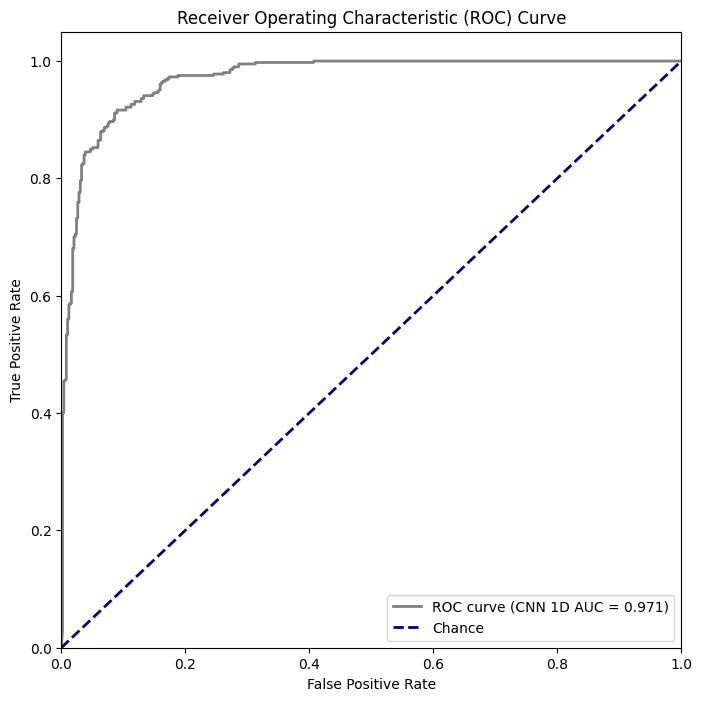

0.9707521241263571


In [ ]:
#predict_classes=np.argmax(predict_prob,axis=1)
from sklearn.metrics import roc_curve, roc_auc_score
probs_cnn_model=cnn_model.predict(X_test)
# calculate roc curves
cnn_model_probs = probs_cnn_model
cnn_model_probs = cnn_model_probs[:, 0]
cnn_model_auc = roc_auc_score(Y_test, cnn_model_probs)
cnn_model_fpr, cnn_model_tpr, threshold = roc_curve(Y_test, cnn_model_probs)
plt.figure(figsize=(8,8))

#plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)
plt.plot(cnn_model_fpr, cnn_model_tpr, color='Grey', lw=2, label='ROC curve (CNN 1D AUC = %0.3f)' % cnn_model_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
#plt.plot(lstm_fpr, lstm_tpr, marker='.', label='LSTM' % lstm_auc)
print(cnn_model_auc)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, matthews_corrcoef, recall_score

# Early Stopping and Learning Rate Reduction Callbacks
earlystop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Define CNN Model
cnn_model2 = Sequential([
    Conv1D(filters=64, kernel_size=3, padding='same', activation='relu', input_shape=(153, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the Model
cnn_model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary
cnn_model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 153, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 76, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 76, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 76, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 38, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 19, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 19, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4864)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       622,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 746,369 (2.85 MB)

 Trainable params: 746,369 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model2.fit(X_train, Y_train, validation_split=0.2,batch_size=32, epochs=100, verbose=1)

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.6453 - loss: 0.6289 - val_accuracy: 0.6430 - val_loss: 0.6267
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6781 - loss: 0.6003 - val_accuracy: 0.7099 - val_loss: 0.5685
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7708 - loss: 0.4729 - val_accuracy: 0.8354 - val_loss: 0.3584
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8347 - loss: 0.3682 - val_accuracy: 0.8773 - val_loss: 0.2906
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8549 - loss: 0.3387 - val_accuracy: 0.8940 - val_loss: 0.2851
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8591 - loss: 0.3172 - val_accuracy: 0.8912 - val_loss: 0.2850
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8720 - loss: 0.2991 - val_accuracy: 0.8689 - val_loss: 0.2826
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8741 - loss: 0.2885 - val_accuracy: 0.

In [ ]:
# Evaluate on Test Set
predictions = cnn_model2.predict(X_test).flatten()
y_pred1 = (predictions > 0.5).astype(int)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [ ]:
# # ----------------------------
# model_file = "cnn_modelfinal_theromoprotein.h5"
# cnn_model2 = load_model(model_file)
# print(f"Loaded CNN model from {model_file}")


# Calculate Metrics
accuracy = accuracy_score(Y_test, y_pred1)
ba = balanced_accuracy_score(Y_test, y_pred1)
cm = confusion_matrix(Y_test, y_pred1)
f1 = f1_score(Y_test, y_pred1)
precision = precision_score(Y_test, y_pred1)
mcc = matthews_corrcoef(Y_test, y_pred1)
recall = recall_score(Y_test, y_pred1)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

# Print Metrics
print("\n--- CNN Test Metrics ---")
print(f"Accuracy: {accuracy * 100:.3f}%")
print(f"Balanced Accuracy: {ba * 100:.3f}%")
print(f"F1-Score: {f1 * 100:.3f}%")
print(f"Precision: {precision * 100:.3f}%")
print(f"Matthews Correlation Coefficient: {mcc:.3f}")
print(f"Sensitivity (Recall): {recall * 100:.3f}%")
print(f"Specificity: {specificity * 100:.3f}%")
print(f"Confusion Matrix:\n{cm}")




--- CNN Test Metrics ---
Accuracy: 91.406%
Balanced Accuracy: 91.344%
F1-Score: 90.552%
Precision: 90.441%
Matthews Correlation Coefficient: 0.827
Sensitivity (Recall): 90.663%
Specificity: 92.025%
Confusion Matrix:
[[450  39]
 [ 38 369]]


In [ ]:
# ----------------------------
# SAVE CNN MODEL
# ----------------------------
model_file = "cnn_model-1Dthermofinal ver2 updated.h5"
cnn_model2.save(model_file)
print(f"CNN model saved as {model_file}")

# ----------------------------
# SAVE RESULTS TO CSV
# ----------------------------
results = {
    "Test Accuracy": accuracy * 100,
    "Test Balanced Accuracy": ba * 100,
    "Test F1": f1 * 100,
    "Test Precision": precision * 100,
    "Test MCC": mcc,
    "Test Sensitivity": recall * 100,
    "Test Specificity": specificity * 100
}

df_results = pd.DataFrame([results])
df_results.to_csv("cnn_results.csv", index=False)
print("CNN results saved to cnn_results.csv")

CNN model saved as cnn_model-1Dthermofinal ver2 updated.h5
CNN results saved to cnn_results.csv


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


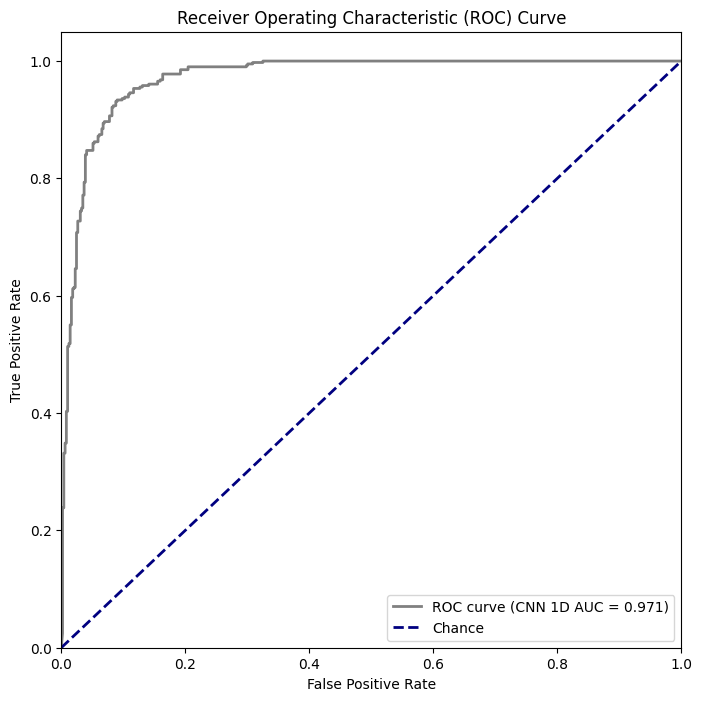

0.9713751676941862


In [ ]:
#predict_classes=np.argmax(predict_prob,axis=1)
from sklearn.metrics import roc_curve, roc_auc_score
probs_cnn_model2=cnn_model2.predict(X_test)
# calculate roc curves
cnn_model2_probs = probs_cnn_model2
cnn_model2_probs = cnn_model2_probs[:, 0]
cnn_model2_auc = roc_auc_score(Y_test, cnn_model2_probs)
cnn_model2_fpr, cnn_model2_tpr, threshold = roc_curve(Y_test, cnn_model2_probs)
plt.figure(figsize=(8,8))

#plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)
plt.plot(cnn_model2_fpr, cnn_model2_tpr, color='Grey', lw=2, label='ROC curve (CNN 1D AUC = %0.3f)' % cnn_model2_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
#plt.plot(lstm_fpr, lstm_tpr, marker='.', label='LSTM' % lstm_auc)
print(cnn_model2_auc)

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, matthews_corrcoef
)


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train),
    y=Y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)


Class Weights: {0: np.float64(0.9161554192229039), 1: np.float64(1.1007371007371007)}


In [ ]:
cnn_model3 = Sequential([

    # Block 1
    Conv1D(64, 3, padding='same', activation='relu',
           kernel_initializer='he_normal',
           input_shape=(153, 1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.25),

    # Block 2
    Conv1D(128, 3, padding='same', activation='relu',
           kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.30),

    # Block 3
    Conv1D(256, 3, padding='same', activation='relu',
           kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.35),

    # Block 4 (critical improvement)
    Conv1D(512, 3, padding='same', activation='relu',
           kernel_initializer='he_normal'),
    BatchNormalization(),
    GlobalAveragePooling1D(),

    # Dense
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
optimizer = Adam(learning_rate=1e-4)

cnn_model3.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model3.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 153, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 153, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 76, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 76, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 76, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 76, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 38, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 19, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 19, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 19, 512)        │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,673 (2.49 MB)

 Trainable params: 650,753 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)


In [ ]:
cnn_model3.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.6397 - loss: 0.6336 - val_accuracy: 0.6276 - val_loss: 0.6441
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.6620 - loss: 0.6197 - val_accuracy: 0.6499 - val_loss: 0.6239
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.6596 - loss: 0.6078 - val_accuracy: 0.5384 - val_loss: 0.6643
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.6641 - loss: 0.6038 - val_accuracy: 0.5718 - val_loss: 0.6538
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.6645 - loss: 0.6109 - val_accuracy: 0.5356 - val_loss: 0.6545
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.6704 - loss: 0.5956 - val_accuracy: 0.5356 - val_loss: 0.7900
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.6700 - loss: 0.6000 - val_accuracy: 0.5356 - val_loss: 0.8594
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.6732 - loss: 0.5952 - va

In [ ]:
predictions = cnn_model3.predict(X_test).ravel()
y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(Y_test, y_pred)

accuracy = accuracy_score(Y_test, y_pred)
balanced_acc = balanced_accuracy_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
mcc = matthews_corrcoef(Y_test, y_pred)
specificity = cm[0,0] / (cm[0,0] + cm[0,1])

print("\n--- Improved CNN Test Metrics ---")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Balanced Accuracy: {balanced_acc*100:.2f}%")
print(f"F1-score: {f1*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Sensitivity (Recall): {recall*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")
print(f"MCC: {mcc:.3f}")
print("Confusion Matrix:\n", cm)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

--- Improved CNN Test Metrics ---
Accuracy: 81.47%
Balanced Accuracy: 79.81%
F1-score: 75.15%
Precision: 96.17%
Sensitivity (Recall): 61.67%
Specificity: 97.96%
MCC: 0.653
Confusion Matrix:
 [[479  10]
 [156 251]]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, matthews_corrcoef, recall_score

In [ ]:
# Define MLP Model
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(153,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the Model
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary
mlp_model.summary()

# Train the Model
mlp_model.fit(X_train, Y_train, validation_split=0.2, batch_size=32, epochs=100, verbose=1)

# Save the trained model
mlp_model.save("mlp_model_final_themo.h5")  # Saved in HDF5 format

# Evaluate on Test Set
predictions = mlp_model.predict(X_test).flatten()
y_pred = (predictions > 0.5).astype(int)

# Calculate Metrics
accuracy = accuracy_score(Y_test, y_pred)
ba = balanced_accuracy_score(Y_test, y_pred)
cm = confusion_matrix(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
mcc = matthews_corrcoef(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

# Print Metrics
print("\n--- MLP Test Metrics ---")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced Accuracy: {ba * 100:.2f}%")
print(f"F1-Score: {f1 * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Sensitivity (Recall): {recall * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"Confusion Matrix:\n{cm}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,081 (117.50 KB)

 Trainable params: 30,081 (117.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7206 - loss: 0.5485 - val_accuracy: 0.8522 - val_loss: 0.3844
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8326 - loss: 0.3591 - val_accuracy: 0.8675 - val_loss: 0.2952
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8682 - loss: 0.2974 - val_accuracy: 0.9107 - val_loss: 0.2198
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8790 - loss: 0.2729 - val_accuracy: 0.9135 - val_loss: 0.2145
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8873 - loss: 0.2581 - val_accuracy: 0.9079 - val_loss: 0.2277
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8891 - loss: 0.2487 - val_accuracy: 0.8912 - val_loss: 0.2418
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8905 - loss: 0.2586 - val_accuracy: 0.9135 - val_loss: 0.2189
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8863 - loss: 0.2489 - val_accuracy: 0.9079 - v

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- MLP Test Metrics ---
Accuracy: 92.97%
Balanced Accuracy: 92.92%
F1-Score: 92.27%
Precision: 92.16%
Matthews Correlation Coefficient: 0.86
Sensitivity (Recall): 92.38%
Specificity: 93.46%
Confusion Matrix:
[[457  32]
 [ 31 376]]


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


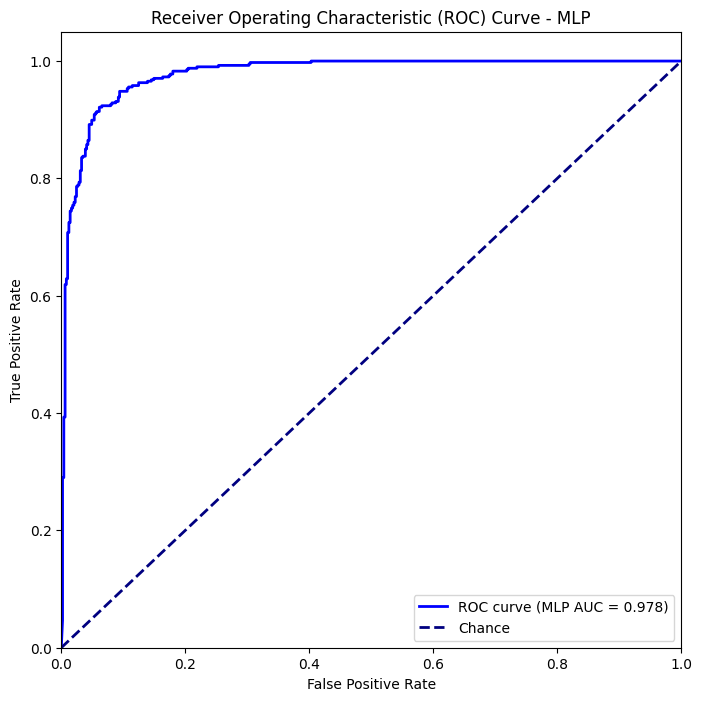

AUC for MLP model: 0.978


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the positive class (class 1)
mlp_probs = mlp_model.predict(X_test).flatten()

# Calculate ROC AUC
mlp_auc = roc_auc_score(Y_test, mlp_probs)

# Compute ROC Curve
mlp_fpr, mlp_tpr, thresholds = roc_curve(Y_test, mlp_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 8))
plt.plot(mlp_fpr, mlp_tpr, color='blue', lw=2, label='ROC curve (MLP AUC = %0.3f)' % mlp_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - MLP')
plt.legend(loc="lower right")
plt.show()

# Print AUC
print("AUC for MLP model: %.3f" % mlp_auc)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define the LSTM model
lstm_model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(153, 1)),
    Dropout(0.2),
    LSTM(64, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 153, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 153, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.fit(X_train, Y_train, validation_split=0.2, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 29s 276ms/step - accuracy: 0.6359 - loss: 0.6285 - val_accuracy: 0.6137 - val_loss: 0.6325
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 258ms/step - accuracy: 0.6495 - loss: 0.6143 - val_accuracy: 0.6402 - val_loss: 0.6255
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 260ms/step - accuracy: 0.6512 - loss: 0.6123 - val_accuracy: 0.6402 - val_loss: 0.6334
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 271ms/step - accuracy: 0.6522 - loss: 0.6116 - val_accuracy: 0.6430 - val_loss: 0.6254
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 254ms/step - accuracy: 0.6536 - loss: 0.6130 - val_accuracy: 0.6137 - val_loss: 0.6314
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 269ms/step - accuracy: 0.6519 - loss: 0.6113 - val_accuracy: 0.6416 - val_loss: 0.6210
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 25s 273ms/step - accuracy: 0.6582 - loss: 0.6021 - val_accuracy: 0.6234 - val_loss: 0.6289
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 266ms/step - accuracy: 0.6603 - loss: 0.6054 - 

In [ ]:
# Make predictions on the test set
lstm_predictions = lstm_model.predict(X_test)
lstm_pred_classes = (lstm_predictions > 0.5).astype(int)

# Evaluate the model
accuracy = accuracy_score(Y_test, lstm_pred_classes)
precision = precision_score(Y_test, lstm_pred_classes)
recall = recall_score(Y_test, lstm_pred_classes)
f1 = f1_score(Y_test, lstm_pred_classes)
roc_auc = roc_auc_score(Y_test, lstm_predictions)

# Confusion Matrix
cm = confusion_matrix(Y_test, lstm_pred_classes)

# Print evaluation metrics
print("LSTM Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(cm)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step
LSTM Model Evaluation Metrics:
Accuracy: 0.8181
Precision: 0.7664
Recall: 0.8624
F1 Score: 0.8116
ROC AUC: 0.9107
Confusion Matrix:
[[382 107]
 [ 56 351]]


In [ ]:
# Save the trained model

lstm_model.save('lstm_model.h5')
print("Model saved as 'lstm_model.h5'")


Model saved as 'lstm_model.h5'


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_lstm_model = load_model('lstm_model.h5')
print("Model loaded successfully.")

# Display the model summary to confirm
loaded_lstm_model.summary()


Model loaded successfully.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 153, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 153, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,083 (461.27 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# Reshape test data (if not already reshaped)
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Make predictions
lstm_predictions = loaded_lstm_model.predict(X_test_lstm)
lstm_pred_classes = (lstm_predictions > 0.5).astype(int)

# Evaluate the loaded model
accuracy = accuracy_score(Y_test, lstm_pred_classes)
print(f"Accuracy of the loaded model: {accuracy:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
Accuracy of the loaded model: 0.8181


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step


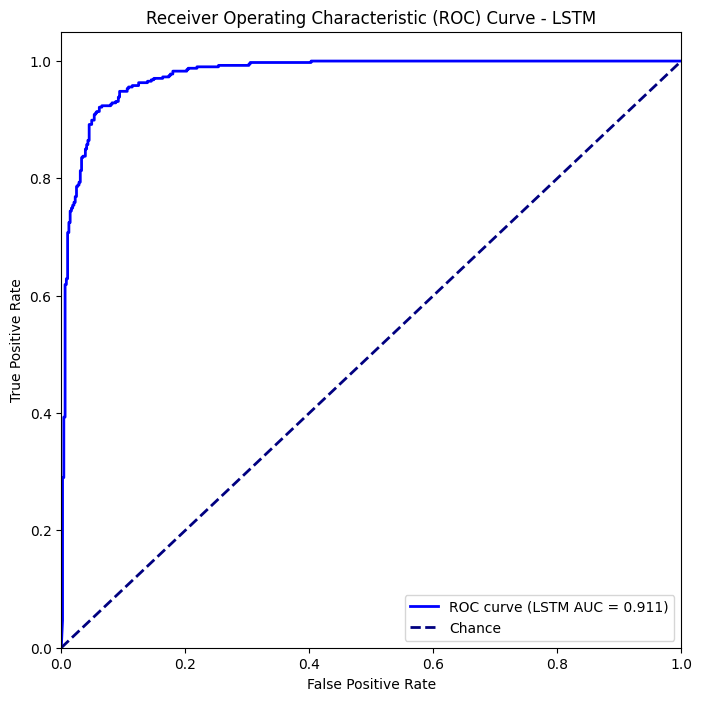

AUC for LSTM model: 0.978


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the positive class (class 1)
lstm_probs = lstm_model.predict(X_test).flatten()

# Calculate ROC AUC
lstm_auc = roc_auc_score(Y_test, lstm_probs)

# Compute ROC Curve
lstm_fpr, lstm_tpr, thresholds = roc_curve(Y_test, lstm_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 8))
plt.plot(mlp_fpr, mlp_tpr, color='blue', lw=2, label='ROC curve (LSTM AUC = %0.3f)' % lstm_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - LSTM')
plt.legend(loc="lower right")
plt.show()

# Print AUC
print("AUC for LSTM model: %.3f" % mlp_auc)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Transformer ka data load karein
# Ensure karein ke files upload ho chuki hain
trans_fpr = np.load('transformer_fpr.npy')
trans_tpr = np.load('transformer_tpr.npy')
trans_auc = np.load('transformer_auc.npy')[0]

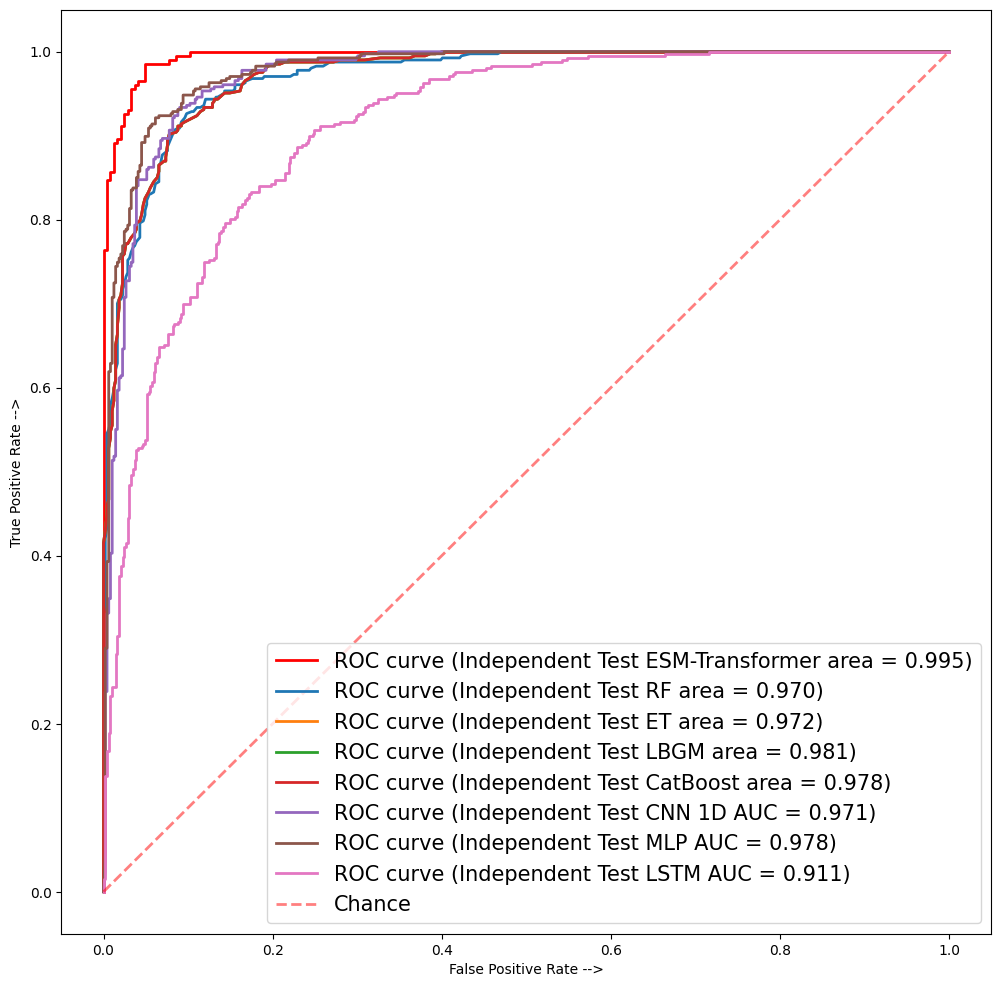

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score


plt.figure(figsize=(12,12))

# plt.plot(fpr_indep, tpr_indep, lw=2, label='ROC curve (Independent Test SVM AUC = %0.3f)' % roc_auc_indep)
plt.plot(trans_fpr, trans_tpr, color='red', lw=2, label='ROC curve (Independent Test ESM-Transformer area = %0.3f)' % trans_auc)
plt.plot(fpr_test, tpr_test, lw=2, label='ROC curve (Independent Test RF area = %0.3f)' % roc_auc_test)
plt.plot(etc_fpr_test, etc_tpr_test, lw=2, label='ROC curve (Independent Test ET area = %0.3f)' % etc_roc_auc_test)
plt.plot(etc_fpr_test, etc_tpr_test, lw=2, label='ROC curve (Independent Test LBGM area = %0.3f)' % lgbm_roc_auc_test)
plt.plot(etc_fpr_test, etc_tpr_test, lw=2, label='ROC curve (Independent Test CatBoost area = %0.3f)' % catb_roc_auc_test)
plt.plot(cnn_model2_fpr, cnn_model2_tpr, lw=2, label='ROC curve (Independent Test CNN 1D AUC = %0.3f)' % cnn_model_auc)
plt.plot(mlp_fpr, mlp_tpr, lw=2, label='ROC curve (Independent Test MLP AUC = %0.3f)' % mlp_auc)
plt.plot(lstm_fpr, lstm_tpr, lw=2, label='ROC curve (Independent Test LSTM AUC = %0.3f)' % lstm_auc)

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.5)
#plt.plot([0, 1], [0, 1],  lw=2, color="r", label="Amino Acid Composition ROC Curve", alpha=0.8)

plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')

plt.legend(loc="lower right", fontsize=15, ncol=1)

plt.show()

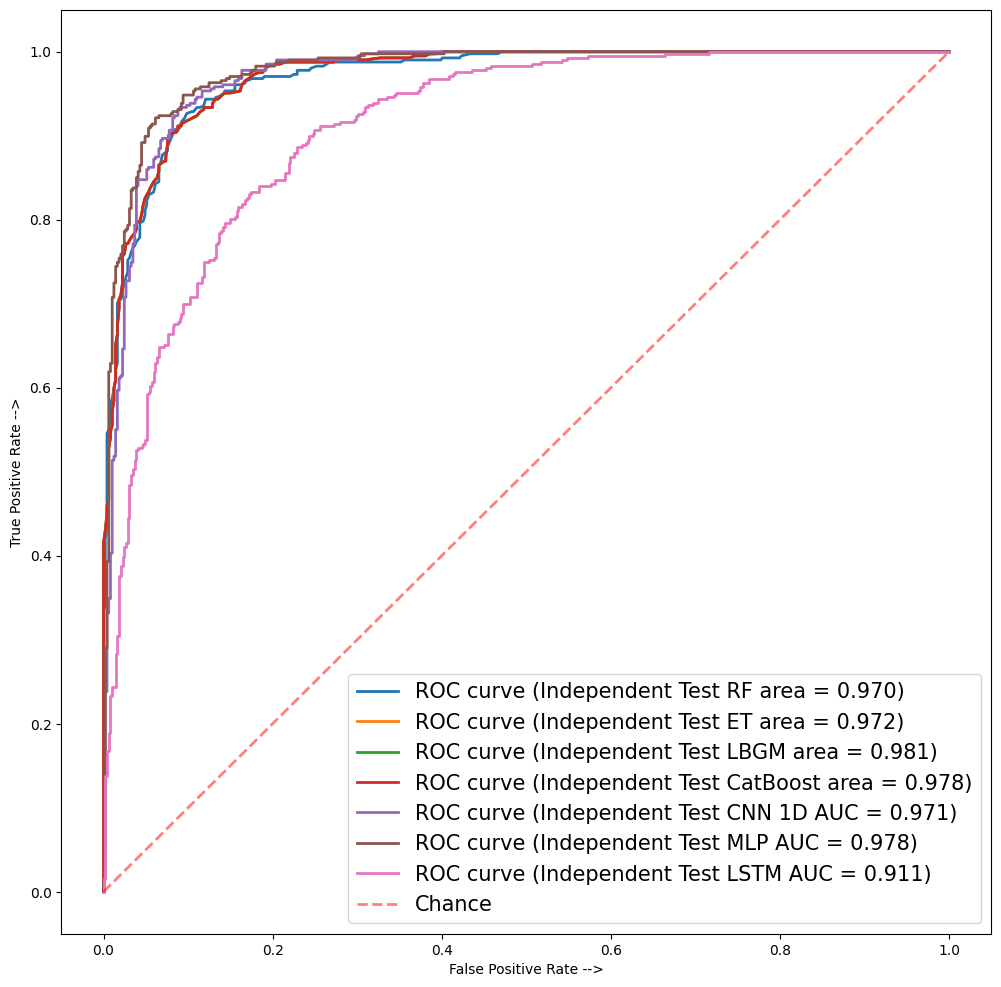

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score


plt.figure(figsize=(12,12))

# plt.plot(fpr_indep, tpr_indep, lw=2, label='ROC curve (Independent Test SVM AUC = %0.3f)' % roc_auc_indep)
plt.plot(fpr_test, tpr_test, lw=2, label='ROC curve (Independent Test RF area = %0.3f)' % roc_auc_test)
plt.plot(etc_fpr_test, etc_tpr_test, lw=2, label='ROC curve (Independent Test ET area = %0.3f)' % etc_roc_auc_test)
plt.plot(etc_fpr_test, etc_tpr_test, lw=2, label='ROC curve (Independent Test LBGM area = %0.3f)' % lgbm_roc_auc_test)
plt.plot(etc_fpr_test, etc_tpr_test, lw=2, label='ROC curve (Independent Test CatBoost area = %0.3f)' % catb_roc_auc_test)
plt.plot(cnn_model2_fpr, cnn_model2_tpr, lw=2, label='ROC curve (Independent Test CNN 1D AUC = %0.3f)' % cnn_model_auc)
plt.plot(mlp_fpr, mlp_tpr, lw=2, label='ROC curve (Independent Test MLP AUC = %0.3f)' % mlp_auc)
plt.plot(lstm_fpr, lstm_tpr, lw=2, label='ROC curve (Independent Test LSTM AUC = %0.3f)' % lstm_auc)

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.5)
#plt.plot([0, 1], [0, 1],  lw=2, color="r", label="Amino Acid Composition ROC Curve", alpha=0.8)

plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')

plt.legend(loc="lower right", fontsize=15, ncol=1)

plt.show()